# 02 Polar Verity Sense Offline Runbook

## A. Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_ROOT = Path.cwd()
LIB_ROOT = NOTEBOOK_ROOT / "lib"
if str(LIB_ROOT) not in sys.path:
    sys.path.insert(0, str(LIB_ROOT))

from session_discovery import list_sessions
from remote_sync import get_session_by_id
from pipeline_client import run_full_pipeline
from session_loader import load_summary, load_clean, load_window_features, load_raw_chunks
from eda_helpers import compute_gap_stats, ensure_datetime, pick_first_column

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

In [2]:
# Runtime parameters
user_id = 1
session_id_override = "a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e"  # set specific session id if needed
user_id_candidates = [1, 2]  # fallback search when session_id_override is set
max_rows_per_stream = 100000
env_path = NOTEBOOK_ROOT / ".env"
plot_points = 4000
live_progress = False  # avoid SSH progress polling loop issues

## B. Session Discovery

In [3]:
sessions = list_sessions(user_id=user_id, env_path=env_path)
offline_sessions = [s for s in sessions if str(s.get("source","")).lower() == "polar_verity_sense" and str(s.get("collection_mode","")).lower() == "offline_recording"]
print(f"discovered={len(sessions)} offline_verity={len(offline_sessions)}")
pd.DataFrame(offline_sessions).head(20)

ssh_command_failed
ssh_command_failed
ssh_command_failed


RemoteSyncError: SSH command failed after 3 attempts: find /data/wearable/raw -type d -path '*/user_id=1/*/session_id=*' 2>/dev/null | sed -E 's#/(streams.*)?$##' || true

In [ ]:
if session_id_override:
    # Resolve correct user_id for explicit session_id override.
    matched_user_id = None
    for candidate_user_id in user_id_candidates:
        try:
            candidate_sessions = list_sessions(user_id=candidate_user_id, env_path=env_path)
        except Exception:
            continue
        if any(str(item.get("session_id")) == str(session_id_override) for item in candidate_sessions):
            matched_user_id = candidate_user_id
            break

    if matched_user_id is not None:
        user_id = matched_user_id
    session_id = session_id_override
elif offline_sessions:
    session_id = str(offline_sessions[0]["session_id"])
else:
    raise RuntimeError("No Polar Verity Sense offline sessions found. Set session_id_override.")

print("user_id:", user_id)
print("session_id:", session_id)


user_id: 1
session_id: a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e


## C. Run Pipeline

In [ ]:
pipeline_result = run_full_pipeline(
    session_id=session_id,
    user_id=user_id,
    env_path=env_path,
    live_progress=False,
)
pipeline_result

Final step summary:
[normalize] status=success streams: success=1 skipped=0 failed=0
[window_features] status=success streams: success=1 skipped=0 failed=0
[build_session_summary] status=partial streams: success=1 skipped=0 failed=0


{'response': {'sessions_discovered': 1,
  'normalize_runs': [{'run_id': 'a90b28439b04421e8d1ad1fd1abf3e4d',
    'status': 'success',
    'session_id': 'a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e',
    'step_name': 'normalize',
    'state_path': '/data/wearable/pipeline_runs/normalize/a90b28439b04421e8d1ad1fd1abf3e4d.json',
    'discovered_streams': ['ppi'],
    'per_stream_results': [{'stream_type': 'ppi',
      'handler_name': 'VeritySenseOfflinePpiNormalizer',
      'status': 'success',
      'input_path': '/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl',
      'output_path': '/data/wearable/processed/clean_timeseries/user_id=2/source=polar_verity_sense/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/data.parquet',
      'error': None}],
    'warnings': ['duration deviates from expected cadence',
     'mixed_valid_invalid_timestamps',
     'ppi invalid_or_zero_timestamps fallback us

## D. Sync Data

In [ ]:
session_cache_path = get_session_by_id(session_id=session_id, env_path=env_path)
print(session_cache_path)

notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e


import json
## E. Load Artifacts

In [ ]:
summary = load_summary(session_cache_path)
clean = load_clean(session_cache_path, max_rows_per_stream=max_rows_per_stream)
window_features = load_window_features(session_cache_path, max_rows_per_stream=max_rows_per_stream)
raw = load_raw_chunks(session_cache_path, preview_rows_per_stream=20, max_scan_lines_per_stream=5000)

print("clean streams:", sorted(clean.keys()))
print("window streams:", sorted(window_features.keys()))
print("raw streams:", sorted(raw.keys()))
summary.get("_source_path")

clean streams: ['ppi']
window streams: ['ppi']
raw streams: ['ppi']


'notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/processed/window_features/user_id=2/source=polar_verity_sense/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/session_summary.json'

## F. Time Alignment Reports

In [ ]:
report_paths = sorted(Path(session_cache_path).glob("**/processed/clean_timeseries/**/time_alignment_report.json"))
reports = []
for p in report_paths:
    payload = json.loads(p.read_text(encoding="utf-8"))
    payload["_path"] = str(p)
    reports.append(payload)

report_df = pd.DataFrame([
    {
        "stream_type": r.get("stream_type"),
        "alignment_basis_level": r.get("alignment_basis_level") or "legacy",
        "alignment_basis": r.get("alignment_basis"),
        "alignment_basis_details": (r.get("alignment_basis_details") or {}).get("selected_reason") if isinstance(r.get("alignment_basis_details"), dict) else r.get("epoch_offset_decision"),
        "confidence": r.get("confidence"),
        "applied_shift_ns": r.get("applied_shift_ns"),
        "samples_count": r.get("samples_count"),
        "session_window_start": r.get("session_window_start") or (r.get("normalized_time_range") or {}).get("start_utc"),
        "session_window_end": r.get("session_window_end") or (r.get("normalized_time_range") or {}).get("end_utc"),
        "per_stream_start": r.get("per_stream_start") or (r.get("normalized_time_range") or {}).get("start_utc"),
        "per_stream_end": r.get("per_stream_end") or (r.get("normalized_time_range") or {}).get("end_utc"),
        "hard_fail_reasons": "; ".join(r.get("hard_fail_reasons") or []),
        "warnings": "; ".join(r.get("warnings") or []),
        "path": r.get("_path"),
    }
    for r in reports
])
report_df.sort_values(["stream_type"]).reset_index(drop=True) if not report_df.empty else report_df


,stream_type,alignment_basis_level,alignment_basis,alignment_basis_details,confidence,applied_shift_ns,samples_count,session_window_start,session_window_end,per_stream_start,per_stream_end,hard_fail_reasons,warnings,path
0,ppi,L1,payload.samples[].timeStamp,shifted_to_reference_hint,low,813352477312518016,23648,2026-05-06T07:13:33.320000Z,2026-05-06T07:22:41.256000Z,2026-05-06T07:13:33.320000Z,2026-05-06T07:22:41.256000Z,,duration deviates from expected cadence; mixed...,notebooks/data_cache/session_id=a3b4f7a4-c810-...


## G. Stream Quality Checks

In [ ]:
rows=[]
for stream, df in clean.items():
    local, ts_col = ensure_datetime(df)
    if ts_col is None or local.empty:
        rows.append({"stream":stream,"rows":len(df.index),"ts_col":ts_col,"duration_s":None,"median_delta_s":None,"max_delta_s":None,"duplicates":None})
        continue
    gaps = compute_gap_stats(local[ts_col])
    duration = (local[ts_col].max() - local[ts_col].min()).total_seconds() if len(local.index)>1 else 0
    rows.append({
        "stream":stream,
        "rows":len(local.index),
        "ts_col":ts_col,
        "duration_s":float(duration),
        "median_delta_s":gaps.median_delta_seconds,
        "max_delta_s":gaps.max_delta_seconds,
        "duplicates":gaps.duplicate_timestamps,
    })

pd.DataFrame(rows).sort_values("stream")

,stream,rows,ts_col,duration_s,median_delta_s,max_delta_s,duplicates
0,ppi,23648,ts_utc,547.936,0.002,75.934,2574


## H. Stream Tables And Plots


### ppi ###


,ts_utc,received_at_collector,uploaded_at_collector,received_at_server,session_id,stream_id,stream_type,payload_schema,user_id,source_vendor,source_device_model,source_device_id,collection_mode,source_chunk_id,source_sequence,source_line_number,alignment_confidence,blocker_bit,hr,pp_error_estimate,pp_in_ms,raw_sample_timestamp_ns,sample_index,skin_contact_status,skin_contact_supported
0,2026-05-06 07:13:33.320000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,39,8,1495,18014336007481984,18920,1,1
1,2026-05-06 07:13:33.451000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,43,11,1370,18014336138481984,19360,1,1
2,2026-05-06 07:13:33.454000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,41,8,1423,18014336141481984,21780,1,1
3,2026-05-06 07:13:33.602814480+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,39,6,1557,0,18919,1,1
4,2026-05-06 07:13:33.611000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,41,4,1452,18014336298481984,17248,1,1
5,2026-05-06 07:13:33.687000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,43,12,1433,18014336374481984,20152,1,1
6,2026-05-06 07:13:33.700000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,41,8,1415,18014336387481984,18656,1,1
7,2026-05-06 07:13:33.711000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,41,7,1395,18014336398481984,20240,1,1
8,2026-05-06 07:13:33.738000+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,43,6,1425,18014336425481984,17336,1,1
9,2026-05-06 07:13:33.885628960+00:00,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,2026-05-06T07:14:37.687956Z,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,ppi,polar.offline.ppi,2,polar,verity_sense,06EDBA31,offline_recording,37030116-46f8-419c-be29-c673f75d906c,1,1,medium,0,39,7,1543,0,18918,1,1


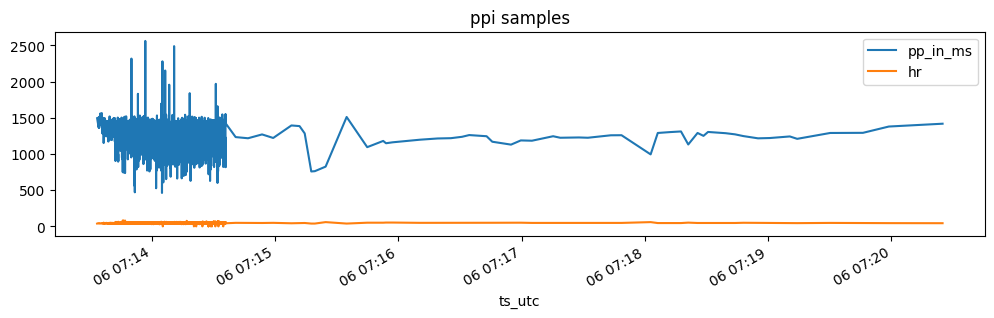

In [ ]:
plot_columns = {
    "hr": ["hr", "corrected_hr"],
    "ppi": ["pp_in_ms", "hr"],
    "acc": ["x", "y", "z", "vector_magnitude"],
    "gyro": ["x", "y", "z", "vector_magnitude"],
    "mag": ["x", "y", "z", "vector_magnitude"],
    "ppg": ["ppg0", "ppg1", "ppg2", "ambient"],
}
for stream, df in sorted(clean.items()):
    print(f"\n### {stream} ###")
    if df.empty:
        print("empty")
        continue
    local, ts_col = ensure_datetime(df)
    display(local.head(10))
    if ts_col is None:
        print("no timestamp column")
        continue
    cols = [c for c in plot_columns.get(stream, []) if c in local.columns]
    if not cols:
        print("no plot columns")
        continue
    sampled = local if len(local.index) <= plot_points else local.iloc[::max(1, len(local.index)//plot_points)].copy()
    ax = sampled.plot(x=ts_col, y=cols, figsize=(12, 3), title=f"{stream} samples")
    ax.set_xlabel("ts_utc")
    plt.show()

## I. Session Summary Snapshot

In [ ]:
if summary:
    print("status:", summary.get("status"))
    print("streams_present:", summary.get("streams_present"))
    print("streams_missing:", summary.get("streams_missing"))
    display(pd.DataFrame(summary.get("stream_summaries", {})).T[["status","warnings"]])
else:
    print("summary missing")

status: partial
streams_present: ['ppi']
streams_missing: ['hr', 'acc', 'ecg', 'battery', 'gyro', 'mag', 'ppg']


,status,warnings
hr,missing,[empty dataset]
acc,missing,[empty dataset]
ecg,missing,[empty dataset]
battery,missing,[empty dataset]
ppi,success,[]
gyro,missing,[empty dataset]
mag,missing,[empty dataset]
ppg,missing,[empty dataset]
